In [33]:
%%duckdb

create or replace table trips as
SELECT
    *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime,['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) as start_at,
    strptime(stoptime,['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) as stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
  using sample 200000 rows
)

,Count
0,200000


In [34]:
%%duckdb

select * from trips
limit 3;

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,241,DeKalb Ave & S Portland Ave,40.689810,-73.974931,324,DeKalb Ave & Hudson Ave,40.689888,-73.981013,15858,Subscriber,1986.0,2,2015-06-25 06:36:00,2015-06-25 06:39:00,3
1,530,11 Ave & W 59 St,40.771522,-73.990541,347,Greenwich St & W Houston St,40.728846,-74.008591,22468,Subscriber,1974.0,1,2016-07-19 20:35:21,2016-07-19 20:53:40,18
2,532,S 5 Pl & S 4 St,40.710451,-73.960876,336,Sullivan St & Washington Sq,40.730477,-73.999061,25923,Customer,NaN,0,2016-06-26 16:46:29,2016-06-26 17:34:50,48


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [ ]:
#distance icin haversine (daha dogru) ve euclidean yaklasim sectim

In [40]:
%%duckdb -o df

select
    duration_min,
    extract(hour from start_at)                        as hour_of_day,
    isodow(start_at)                                   as day_of_week,
    case when isodow(start_at) in (6,7) then 1 else 0 end as weekend,
    st_distance_sphere(
        st_point("start station longitude", "start station latitude"),
        st_point("end station longitude",   "end station latitude")
    ) / 1000.0 as distance_sphere_km,
    sqrt(
        pow(("start station latitude"  - "end station latitude" ) * 111.0, 2) +
        pow(("start station longitude" - "end station longitude") *  85.0, 2)
    ) as distance_simple_km,
    1 as bias
from trips
where duration_min > 0 and duration_min < 120
  and "start station latitude" is not null
  and "end station latitude"   is not null
using sample 100000 rows

,duration_min,hour_of_day,day_of_week,weekend,distance_sphere_km,distance_simple_km,bias
0,15,17,1,0,1.874337,3.109754,1
1,12,14,4,0,1.435875,1.537552,1
2,15,20,3,0,0.895855,2.432488,1
3,23,16,3,0,3.139876,3.393102,1
4,7,8,3,0,1.294789,1.367915,1
...,...,...,...,...,...,...,...
99535,19,17,7,1,1.112502,2.714736,1
99536,5,8,7,1,0.224779,0.792086,1
99537,13,7,6,1,1.460241,1.284560,1
99538,14,12,3,0,1.548855,1.433095,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate(feature_list, model=None):
    m = model or LinearRegression(fit_intercept=False)
    x_train, x_test, y_train, y_test = train_test_split(
        df[feature_list], df["duration_min"], test_size=0.2, random_state=42
    )
    m.fit(x_train, y_train)
    p = m.predict(x_test)
    return {
        "features": " + ".join(feature_list),
        "mae":  round(mean_absolute_error(y_test, p), 3),
        "rmse": round(np.sqrt(mean_squared_error(y_test, p)), 3),
        "r2":   round(r2_score(y_test, p), 4)
    }

In [ ]:
# distance karsilastirma + farkli feature kombinasyonlari
results = [
    evaluate(["distance_sphere_km", "bias"]),
    evaluate(["distance_simple_km", "bias"]),
    evaluate(["hour_of_day",        "bias"]),
    evaluate(["day_of_week",        "bias"]),
    evaluate(["weekend",            "bias"]),
    evaluate(["distance_sphere_km", "hour_of_day", "bias"]),
    evaluate(["distance_sphere_km", "hour_of_day", "day_of_week", "bias"]),
    evaluate(["distance_sphere_km", "hour_of_day", "day_of_week", "weekend", "bias"]),
    evaluate(["distance_simple_km", "hour_of_day", "day_of_week", "weekend", "bias"]),
    # Lasso denedim linear regden kotu
    evaluate(["distance_sphere_km", "hour_of_day", "day_of_week", "weekend", "bias"],
             Lasso(alpha=0.1, fit_intercept=False)),
]

pd.DataFrame(results).sort_values("r2", ascending=False)

In [41]:
# final model
best_features = ["distance_sphere_km", "hour_of_day", "day_of_week", "weekend", "bias"]

x_train, x_test, y_train, y_test = train_test_split(
    df[best_features], df["duration_min"], test_size=0.2, random_state=42
)

model = LinearRegression(fit_intercept=False)
model.fit(x_train, y_train)
pred = model.predict(x_test)

print(f"MAE : {mean_absolute_error(y_test, pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f}")
print(f"R2  : {r2_score(y_test, pred):.4f}")

print("\nCoefficients:")
for f, c in zip(best_features, model.coef_):
    label = "bias (intercept)" if f == "bias" else f
    print(f"  {label:<25}: {c:.4f}")

MAE : 8.260
RMSE: 300.234
R2  : -791.2684

Coefficients:
  distance_sphere_km       : 4.8859
  hour_of_day              : 0.0766
  day_of_week              : 0.0384
  weekend                  : 2.6359
  bias (intercept)         : 5.3904


In [42]:
result = x_test.copy()
result["actual"]    = y_test.values
result["predicted"] = pred.round(2)
result.head(10)

,distance_sphere_km,hour_of_day,day_of_week,weekend,bias,actual,predicted
1318,0.851673,8,3,0,1,22,10.28
26491,1.202737,8,3,0,1,15,11.99
9724,0.842200,18,1,0,1,25,10.92
80132,1.490102,18,3,0,1,22,14.17
15272,2.543620,16,6,1,1,20,21.91
96587,0.353199,19,3,0,1,4,8.69
95714,0.671190,22,4,0,1,6,10.51
37925,0.826240,19,3,0,1,8,11.00
66878,0.000000,16,7,1,1,1,9.52
33140,1.496692,7,2,0,1,7,13.32


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speek_{bike} = x | gender = a)
$$

- Note that $P(speek_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speek_{bike} = x | gender = a)$ modeled

In [27]:
%%duckdb -o gender_df

select gender, st_distance_sphere(
    st_point("start station longitude", "start station latitude"),
    st_point("end station longitude",   "end station latitude") ) / 1000.0 / duration_min as speed_km_per_min

from trips

where gender in (1, 2)
  and duration_min > 0 and duration_min < 120
  and "start station latitude" is not null
  and "end station latitude"   is not null

using sample 50000 rows

,gender,speed_km_per_min
0,1,0.000000
1,2,0.038339
2,1,0.038568
3,1,0.096107
4,1,0.190032
...,...,...
43628,1,0.205234
43629,1,0.115088
43630,1,0.074273
43631,1,0.041879


In [24]:
# outlier atma
gender_df = gender_df[
    (gender_df["speed_km_per_min"] > 0) &
    (gender_df["speed_km_per_min"] < 1.0)
].copy()

print(gender_df["gender"].value_counts())

Gender dagilimi:
gender
1    32695
2    10319
Name: count, dtype: int64


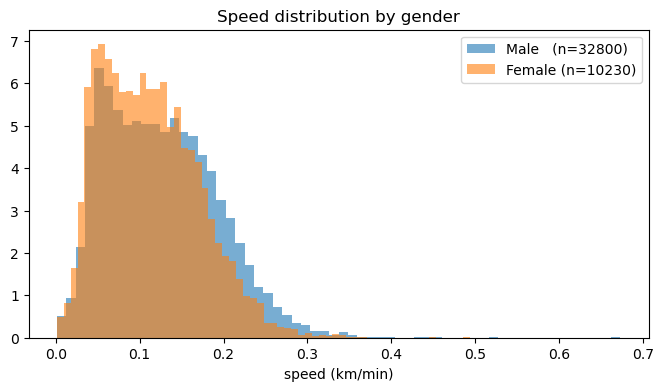

Male   — mean: 0.1262, std: 0.0659
Female — mean: 0.1122, std: 0.0579


In [28]:
import matplotlib.pyplot as plt

gender_df = gender_df[(gender_df["speed_km_per_min"] > 0) & (gender_df["speed_km_per_min"] < 1.0)].copy()

male   = gender_df[gender_df["gender"] == 1]["speed_km_per_min"]
female = gender_df[gender_df["gender"] == 2]["speed_km_per_min"]

plt.figure(figsize=(8, 4))
plt.hist(male,   bins=60, alpha=0.6, density=True, label=f"Male   (n={len(male)})")
plt.hist(female, bins=60, alpha=0.6, density=True, label=f"Female (n={len(female)})")
plt.xlabel("speed (km/min)")
plt.title("Speed distribution by gender")
plt.legend()
plt.show()

# dagilim normal, gausssian nb kullanacagiz
print(f"Male   — mean: {male.mean():.4f}, std: {male.std():.4f}")
print(f"Female — mean: {female.mean():.4f}, std: {female.std():.4f}")

#Sadece hiz ile gender ayirt etmek zor

In [29]:
from scipy.stats import norm

# prior ve gaussian parametreler
total  = len(gender_df)
prior  = {g: (gender_df["gender"] == g).sum() / total for g in [1, 2]}
params = {g: {"mu": gender_df[gender_df["gender"] == g]["speed_km_per_min"].mean(),
              "sg": gender_df[gender_df["gender"] == g]["speed_km_per_min"].std()} for g in [1, 2]}

def predict_gender(speed):
    scores = {g: prior[g] * norm.pdf(speed, params[g]["mu"], params[g]["sg"]) for g in [1, 2]}
    return max(scores, key=scores.get)

# test
train_df, test_df = train_test_split(gender_df, test_size=0.2, random_state=42)
test_df = test_df.copy()
test_df["pred"] = test_df["speed_km_per_min"].apply(predict_gender)

accuracy = (test_df["gender"] == test_df["pred"]).mean()
print(f"Manuel Gaussian NB accuracy: {accuracy:.4f}")

#  model prior'u da (male cok daha fazla) kullanarak makul accuracy veriyor

Manuel Gaussian NB accuracy: 0.7637


In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X = gender_df[["speed_km_per_min"]]
y = gender_df["gender"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb = GaussianNB().fit(X_train, y_train)
print(f"Sklearn GaussianNB accuracy: {accuracy_score(y_test, gnb.predict(X_test)):.4f}")

# confusion matrix
pd.crosstab(y_test, gnb.predict(X_test), rownames=["actual"], colnames=["predicted"])

# manuelim ile sklearn sonucu esit

Sklearn GaussianNB accuracy: 0.7637


predicted,1
actual,
1,6572
2,2034
